In [60]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

# Normalize pixel values to be between 0 and 1
x_train, x_test = x_train / 255.0, x_test / 255.0

In [ ]:
# Changing the data labels into binary for a chosen class in the dataset. Here we have chosen frogs, and all the labels who is not a
# a frog will be 0 and vice verse if it is a frog.
num_class = 6

for n in range(len(y_train)):
    if y_train[n] == [num_class]:
        y_train[n] = [1]
    else:
        y_train[n] = [0]

for n in range(len(y_test)):
    if y_test[n] == [num_class]:
        y_test[n] = [1]
    else:
        y_test[n] = [0]

In [63]:
from tensorflow.keras import callbacks

with tf.device('/GPU:0'):
    model = models.Sequential()
    model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))

    model.add(layers.Conv2D(128, (3, 3), activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))

    model.add(layers.Conv2D(256, (3, 3), activation='relu'))
    model.add(layers.BatchNormalization())

    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.005)))
    model.add(layers.Dropout(0.4))
    model.add(layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.005)))
    model.add(layers.Dropout(0.4))
    model.add(layers.Dense(1, activation='sigmoid'))

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience = 5, restore_best_weights = True)

    history = model.fit(
        x_train,
        y_train,
        batch_size = 32,
        epochs = 10,
        validation_data = (x_test, y_test),
        callbacks = [early_stopping]
    )

c:\Users\dhaaa\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 25s 15ms/step - accuracy: 0.9018 - loss: 1.0305 - val_accuracy: 0.9028 - val_loss: 0.5487
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.9361 - loss: 0.2362 - val_accuracy: 0.9320 - val_loss: 0.2267
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.9448 - loss: 0.2103 - val_accuracy: 0.9403 - val_loss: 0.2175
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.9476 - loss: 0.2035 - val_accuracy: 0.9378 - val_loss: 0.2212
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 0.9567 - loss: 0.1812 - val_accuracy: 0.9529 - val_loss: 0.1925
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.9602 - loss: 0.1727 - val_accuracy: 0.9092 - val_loss: 0.4781
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.9609 - loss: 0.1666 - val_accuracy: 0.9430 - val_loss: 0.2098
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.9657 -

313/313 - 1s - 4ms/step - accuracy: 0.9567 - loss: 0.1808


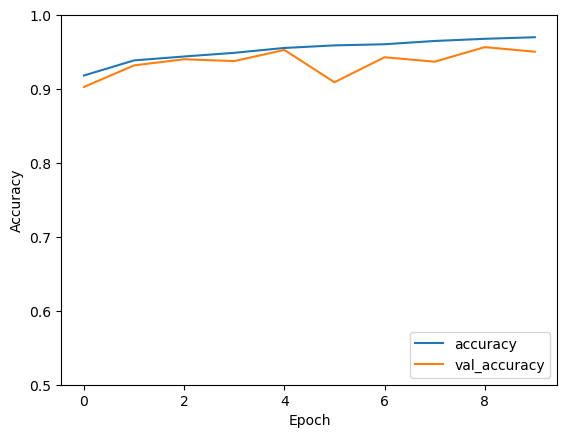

In [64]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')

test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)

In [ ]:
image = cv2.imread('./media/frog_5.jpg')

img = tf.keras.utils.load_img('./media/frog_5.jpg', target_size=(32, 32))

img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, 0) # Create a batch
img_array = img_array / 255.0
prediction = model.predict(img_array)
if max(prediction) == 1:
    print('frog')
else:
    print('not frog')

tf.Tensor(
[[[[0.96862745 0.96862745 1.        ]
   [0.96862745 0.96862745 1.        ]
   [0.96862745 0.96862745 1.        ]
   ...
   [0.9764706  0.98039216 1.        ]
   [0.9764706  0.98039216 1.        ]
   [0.972549   0.9764706  0.99607843]]

  [[0.96862745 0.96862745 1.        ]
   [0.96862745 0.96862745 1.        ]
   [0.96862745 0.96862745 1.        ]
   ...
   [0.9764706  0.98039216 1.        ]
   [0.9764706  0.98039216 1.        ]
   [0.972549   0.9764706  0.99607843]]

  [[0.96862745 0.96862745 1.        ]
   [0.96862745 0.96862745 1.        ]
   [0.96862745 0.96862745 1.        ]
   ...
   [0.9764706  0.98039216 1.        ]
   [0.98039216 0.9764706  1.        ]
   [0.9764706  0.98039216 1.        ]]

  ...

  [[0.972549   0.9764706  0.99607843]
   [0.972549   0.9764706  0.99607843]
   [0.972549   0.9764706  0.99607843]
   ...
   [0.9843137  0.98039216 1.        ]
   [0.9882353  0.9843137  1.        ]
   [0.9843137  0.98039216 1.        ]]

  [[0.972549   0.9764706  0.996078